# Визуализация небольшой CNN на синтетическом датасете Кошки vs Собаки

Цель: обучить небольшую CNN на синтетических рисунках кошки и собаки и визуализировать, на что обращает внимание каждый слой.

Кошка: круглая голова + острые треугольные уши

Собака: овальная голова + висячие уши

Визуализации:
1. Послойные сводки признаков
2. Grad-CAM


## Подготовка окружения

В этом разделе устанавливаем зависимости и импортируем библиотеки, необходимые для обучения модели и визуализаций.


In [62]:
!pip -q install torch torchvision matplotlib numpy pillow
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

## Настройка воспроизводимости и устройства

Фиксируем генераторы случайных чисел и выбираем вычислительное устройство (CPU или GPU).


In [63]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

## Синтетический датасет: кошки и собаки

Генерируем изображения 64x64.

Признаки кошки:
круглая голова, два острых уха

Признаки собаки:
овальная голова, висячие уши


### Реализация синтетического датасета

Ниже реализуем класс датасета, который генерирует изображения и метки классов.


In [64]:
class CatDogToyDataset(Dataset):
    def __init__(self, n=4000, img_size=64, seed=42):
        self.n = n
        self.img_size = img_size
        rng = np.random.default_rng(seed)
        self.labels = rng.integers(0, 2, size=n)  # 0 cat, 1 dog

    def __len__(self):
        return self.n

    def _mirror_points(self, pts, cx):
        return [(2*cx - x, y) for (x, y) in pts]

    def _draw_cat(self, draw, cx, cy, r):
      draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=255)

      ear_h = int(r * random.uniform(0.85, 1.25))
      ear_w = int(r * random.uniform(0.55, 0.85))
      tilt  = int(r * random.uniform(0.05, 0.18))

      base_y = cy - r + int(0.06 * r)
      left_base_x = cx - int(0.55 * r)

      left_ear = [
          (left_base_x, base_y),
          (left_base_x - ear_w//2, base_y - ear_h),
          (left_base_x + ear_w//2 + tilt, base_y),
      ]
      right_ear = [(2*cx - x, y) for (x, y) in left_ear]

      draw.polygon(left_ear, fill=255)
      draw.polygon(right_ear, fill=255)

      ex = int(r * random.uniform(0.35, 0.50))
      ey = cy - int(r * random.uniform(0.10, 0.20))
      er = max(1, int(r * random.uniform(0.07, 0.10)))
      for s in (-1, 1):
          draw.ellipse([cx+s*ex-er, ey-er, cx+s*ex+er, ey+er], fill=0)

      if random.random() < 0.9:
          ny = cy + int(r * random.uniform(0.10, 0.22))
          nw = max(2, int(r * random.uniform(0.10, 0.16)))
          nh = max(2, int(r * random.uniform(0.08, 0.12)))
          nose = [(cx, ny), (cx-nw, ny+nh), (cx+nw, ny+nh)]
          draw.polygon(nose, fill=0)

      wlen = int(r * random.uniform(0.75, 1.10))
      wy = cy + int(r * random.uniform(0.08, 0.22))
      for s in (-1, 1):
          x0 = cx + s*int(0.18*r)
          for k in (-1, 0, 1):
              yk = wy + k*int(0.16*r)
              draw.line([(x0, yk), (x0 + s*wlen, yk - k*int(0.10*r))], fill=255, width=1)

    def _draw_dog(self, draw, cx, cy, r):
        w = int(r * random.uniform(1.05, 1.35))
        h = int(r * random.uniform(0.95, 1.20))
        draw.ellipse([cx-w, cy-h, cx+w, cy+h], fill=255)

        style = "droop"

        if style == "droop":
            ew = int(r * random.uniform(0.55, 0.85))
            eh = int(r * random.uniform(0.55, 0.95))
            y0 = cy - int(0.35*r)
            draw.ellipse([cx-w-ew, y0, cx-w+ew, y0+eh], fill=255)
            draw.ellipse([cx+w-ew, y0, cx+w+ew, y0+eh], fill=255)


            sn_w = int(r * random.uniform(0.35, 0.50))
            sn_h = int(r * random.uniform(0.25, 0.30))
            sn_y = cy + int(r * random.uniform(0.15, 0.35))
            draw.ellipse([cx-sn_w, sn_y-sn_h, cx+sn_w, sn_y+sn_h], fill=0)


            ex = int(r * random.uniform(0.35, 0.55))
            ey = cy - int(r * random.uniform(0.05, 0.20))
            er = max(1, int(r * random.uniform(0.06, 0.10)))
            for s in (-1, 1):
                draw.ellipse([cx+s*ex-er, ey-er, cx+s*ex+er, ey+er], fill=0)

    def __getitem__(self, idx):
        label = int(self.labels[idx])
        S = self.img_size

        img = Image.new("L", (S, S), 0)
        draw = ImageDraw.Draw(img)

        cx = random.randint(int(0.35*S), int(0.65*S))
        cy = random.randint(int(0.40*S), int(0.65*S))
        r  = random.randint(int(0.16*S), int(0.26*S))

        cx += random.randint(-6, 6)
        cy += random.randint(-6, 6)
        cx = max(r+2, min(S-r-2, cx))
        cy = max(r+2, min(S-r-2, cy))

        if label == 0:
            self._draw_cat(draw, cx, cy, r)
        else:
            self._draw_dog(draw, cx, cy, r)

        x = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


### Примеры сгенерированных изображений

Построим небольшую сетку примеров, чтобы визуально проверить корректность генерации и различимость классов.


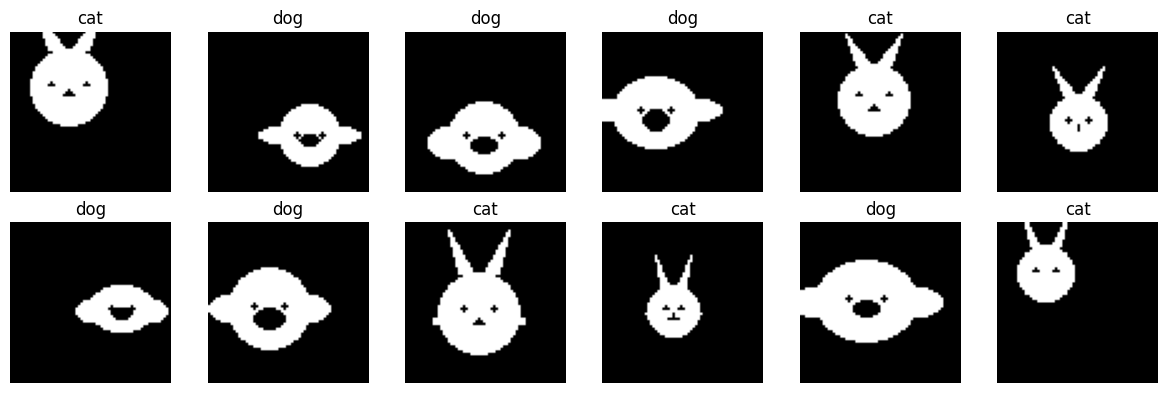

In [65]:
def show_grid(ds, n=12, title_fn=None):
    fig, axes = plt.subplots(2, n//2, figsize=(12, 4))
    axes = axes.flatten()
    for i in range(n):
        x, y = ds[i]
        axes[i].imshow(x.squeeze(0), cmap="gray")
        axes[i].axis("off")
        if title_fn:
            axes[i].set_title(title_fn(int(y)))
    plt.tight_layout()
    plt.show()

tmp = CatDogToyDataset(n=12, seed=1)
show_grid(tmp, n=12, title_fn=lambda y: "cat" if y == 0 else "dog")


### Выводы по датасету

Данные синтетические: модель учится распознавать заданные нами различия (в первую очередь форму ушей)

Такой датасет удобен для интерпретации: легко понять, на что смотрит сеть.


## Модель: небольшая CNN


In [66]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc  = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = self.pool2(x)

        x = F.relu(self.conv4(x))
        x = self.gap(x).squeeze(-1).squeeze(-1)
        return self.fc(x)


### Выводы по модели

Используется компактная CNN с несколькими свёрточными слоями и глобальным усредняющим пулингом (GAP) перед классификатором.

Архитектура хорошо подходит для небольших изображений и быстрой отладки.

Такая модель позволяет удобно смотреть активации слоёв и связывать их с визуальными признаками.


## Загрузчики данных и утилиты обучения


In [67]:
def make_loaders(dataset, batch_size=64, split=0.8, seed=42):
    n = len(dataset)
    n_train = int(split * n)
    n_val = n - n_train
    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=g)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_ds, val_ds, train_loader, val_loader

@torch.no_grad()
def accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

def train(model, train_loader, val_loader, device, epochs=5, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for ep in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item()
        val_acc = accuracy(model, val_loader, device)
        print(f"epoch {ep} | loss {loss_sum/len(train_loader):.4f} | val acc {val_acc:.3f}")
    return model


## Обучение


In [68]:
dataset = CatDogToyDataset(n=5000, img_size=64, seed=42)
train_ds, val_ds, train_loader, val_loader = make_loaders(dataset, batch_size=64, split=0.8, seed=42)

model = SmallCNN(n_classes=2).to(device)
model = train(model, train_loader, val_loader, device, epochs=6, lr=1e-3)


epoch 1 | loss 0.5876 | val acc 1.000
epoch 2 | loss 0.0162 | val acc 1.000
epoch 3 | loss 0.0007 | val acc 1.000
epoch 4 | loss 0.0003 | val acc 1.000
epoch 5 | loss 0.0002 | val acc 1.000
epoch 6 | loss 0.0001 | val acc 1.000


## Извлечение признаков


In [69]:
@torch.no_grad()
def forward_activations(model, x):
    model.eval()
    acts = {}

    x = x.unsqueeze(0).to(device)

    x = F.relu(model.conv1(x)); acts["conv1"] = x.detach().cpu()
    x = F.relu(model.conv2(x)); acts["conv2"] = x.detach().cpu()
    x = model.pool1(x);         acts["pool1"] = x.detach().cpu()
    x = F.relu(model.conv3(x)); acts["conv3"] = x.detach().cpu()
    x = model.pool2(x);         acts["pool2"] = x.detach().cpu()
    x = F.relu(model.conv4(x)); acts["conv4"] = x.detach().cpu()

    return acts


## Сводные карты активаций слоёв

среднее по каналам: более гладкая общая активность слоя

максимум по каналам: подчёркивает сильные детекторы (часто лучше видно уши и контуры)


In [70]:
def norm01(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

def summarize_mean(act):
    return norm01(act[0].mean(dim=0).numpy())

def summarize_max(act):
    return norm01(act[0].amax(dim=0).numpy())


## Сравнение кошки и собаки по слоям


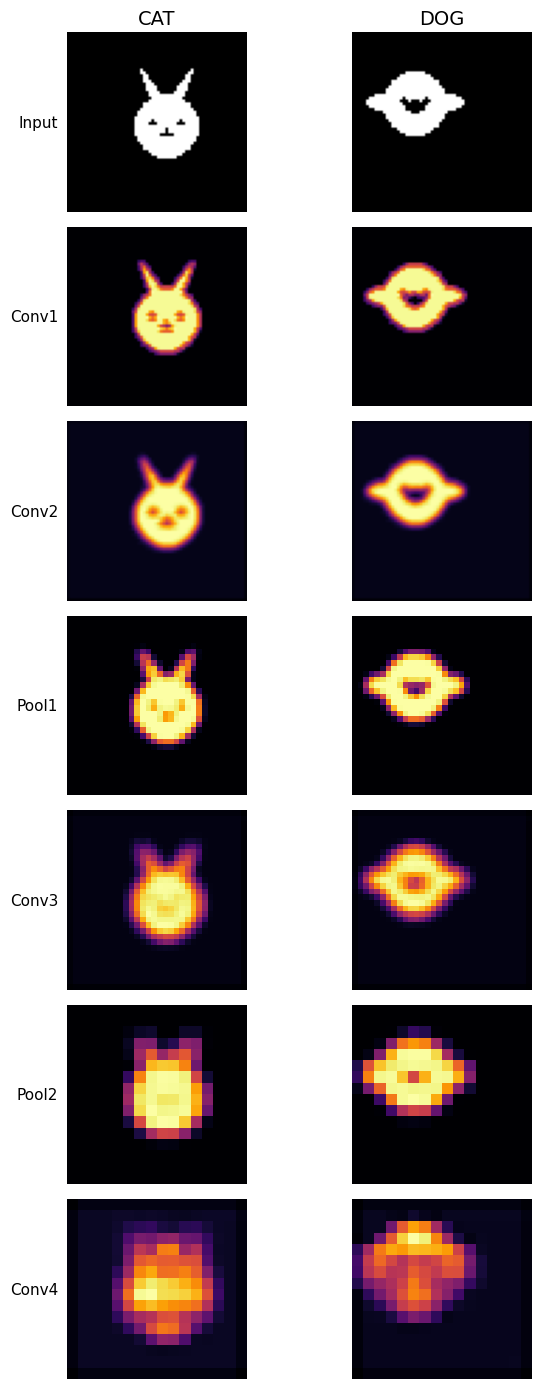

In [71]:
def find_example(ds, target_label):
    for i in range(len(ds)):
        x, y = ds[i]
        if int(y) == target_label:
            return x, y
    raise RuntimeError("Example not found")

def compare_layers(model, x_cat, x_dog, mode="max"):
    acts_cat = forward_activations(model, x_cat)
    acts_dog = forward_activations(model, x_dog)

    summary = summarize_max if mode == "max" else summarize_mean

    layers = [("Input", None), ("Conv1", "conv1"), ("Conv2", "conv2"),
              ("Pool1", "pool1"), ("Conv3", "conv3"), ("Pool2", "pool2"), ("Conv4", "conv4")]

    fig, axes = plt.subplots(len(layers), 2, figsize=(7, 14))
    axes[0, 0].set_title("CAT", fontsize=14)
    axes[0, 1].set_title("DOG", fontsize=14)

    for r, (name, key) in enumerate(layers):
        for c, (x, acts) in enumerate([(x_cat, acts_cat), (x_dog, acts_dog)]):
            ax = axes[r, c]
            ax.axis("off")
            if key is None:
                ax.imshow(x.squeeze(0).numpy(), cmap="gray")
            else:
                ax.imshow(summary(acts[key]), cmap="inferno")
        axes[r, 0].text(-0.05, 0.5, name, transform=axes[r, 0].transAxes,
                        ha="right", va="center", fontsize=11)

    plt.tight_layout()
    plt.show()

x_cat, _ = find_example(val_ds, 0)
x_dog, _ = find_example(val_ds, 1)

compare_layers(model, x_cat, x_dog, mode="max")


### Выводы по картам активаций

На ранних слоях обычно проявляются детекторы простых признаков: границы, контуры, локальные пятна.

В более глубоких слоях активации становятся семантичнее: усиливаются области, связанные с ушами/мордами.

Сравнение кошка vs собака по слоям помогает увидеть, на каких признаках сеть разделяет классы.


## Top-K каналов, реагирующих на уши

Оценим каналы по средней активации внутри выбранной области интереса (ROI) в верхней части изображения (примерно там, где находятся уши).

Далее выведем и визуализируем каналы с наибольшими значениями (Top-K) отдельно для кошек и собак.

cat top channels: [46, 15, 32, 1, 59, 57]
dog top channels: [15, 1, 46, 59, 28, 32]


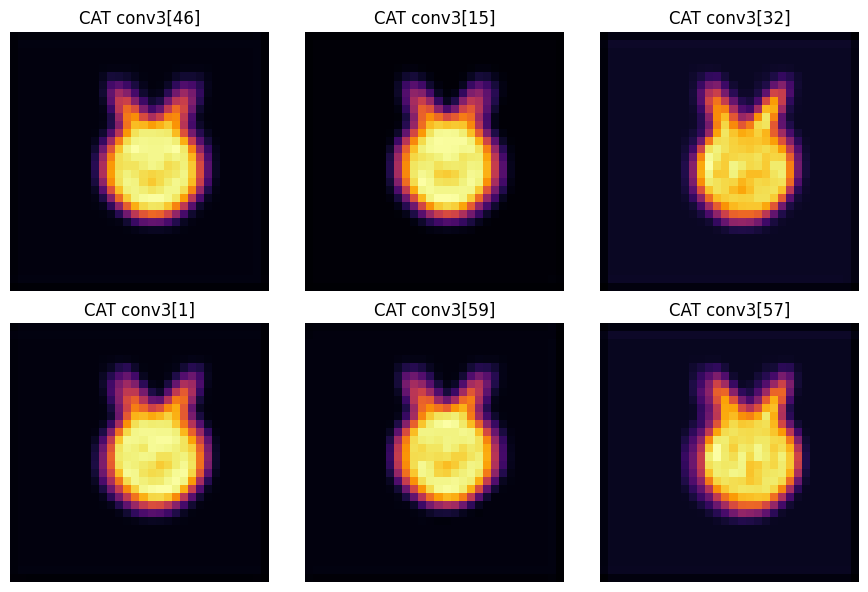

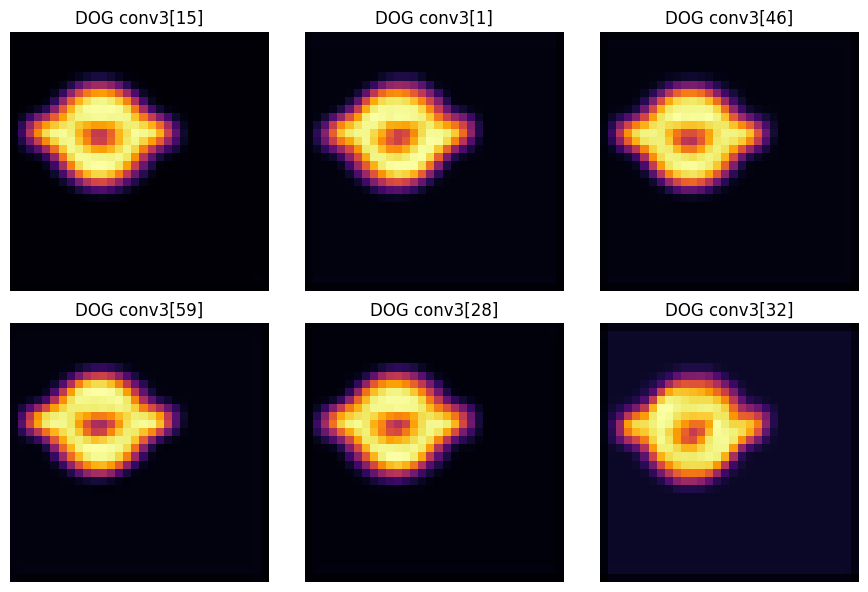

In [72]:
def topk_channels_in_roi(act, roi, k=6):
    fm = act[0]  # [C,H,W]
    y0, y1, x0, x1 = roi
    scores = fm[:, y0:y1, x0:x1].mean(dim=(1, 2))
    return torch.topk(scores, k=min(k, fm.shape[0])).indices.tolist()

def show_channels(act, channels, title, cols=3):
    fm = act[0]
    rows = math.ceil(len(channels) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = np.array(axes).reshape(-1)
    for i, ch in enumerate(channels):
        img = norm01(fm[ch].detach().cpu().numpy())
        axes[i].imshow(img, cmap="inferno")
        axes[i].set_title(f"{title}[{ch}]")
        axes[i].axis("off")
    for j in range(i+1, rows*cols):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

acts_cat = forward_activations(model, x_cat)
acts_dog = forward_activations(model, x_dog)

layer_key = "conv3"
_, H, W = acts_cat[layer_key].shape[1:]
ear_roi = (0, H//3, W//4, 3*W//4)

top_cat = topk_channels_in_roi(acts_cat[layer_key], ear_roi, k=6)
top_dog = topk_channels_in_roi(acts_dog[layer_key], ear_roi, k=6)

print("cat top channels:", top_cat)
print("dog top channels:", top_dog)

show_channels(acts_cat[layer_key], top_cat, title=f"CAT {layer_key}")
show_channels(acts_dog[layer_key], top_dog, title=f"DOG {layer_key}")


### Выводы по Top-K каналам ушей

Подсчёт средней активации в ROI позволяет найти каналы, которые сильнее всего реагируют на выбранную область.

Списки top_cat и top_dog могут отличаться: это означает, что сеть использует разные наборы фильтров для кошачьих и собачьих ушей.

Просмотр карт отдельных каналов - это быстрый способ найти интерпретируемые детекторы.

## Grad-CAM: что повлияло на финальное решение

Grad-CAM строит тепловую карту поверх входного изображения и показывает, какие области внесли наибольший вклад в решение модели по выбранному классу.

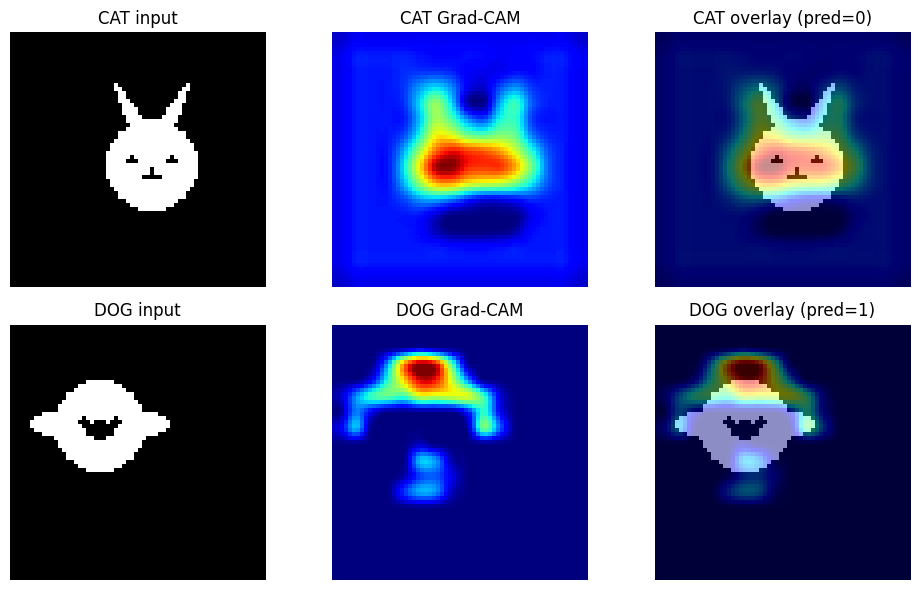

In [73]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activ = None
        self.grad = None
        self.h1 = target_layer.register_forward_hook(self._fw)
        self.h2 = target_layer.register_full_backward_hook(self._bw)

    def _fw(self, module, inp, out):
        self.activ = out

    def _bw(self, module, grad_in, grad_out):
        self.grad = grad_out[0]

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        weights = self.grad.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activ).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().detach().cpu().numpy()
        return norm01(cam), class_idx

    def close(self):
        self.h1.remove()
        self.h2.remove()

def resize_cam(cam, H, W):
    return np.array(Image.fromarray((cam*255).astype(np.uint8)).resize((W, H))).astype(np.float32) / 255.0

def show_gradcam_pair(model, x_cat, x_dog, target_layer):
    gc = GradCAM(model, target_layer)

    model.eval()
    xC = x_cat.unsqueeze(0).to(device).requires_grad_(True)
    xD = x_dog.unsqueeze(0).to(device).requires_grad_(True)

    camC, predC = gc(xC)
    camD, predD = gc(xD)
    gc.close()

    imgC = x_cat.squeeze(0).cpu().numpy()
    imgD = x_dog.squeeze(0).cpu().numpy()

    heatC = resize_cam(camC, *imgC.shape)
    heatD = resize_cam(camD, *imgD.shape)

    fig, axes = plt.subplots(2, 3, figsize=(10, 6))

    axes[0, 0].imshow(imgC, cmap="gray"); axes[0, 0].set_title("CAT input"); axes[0, 0].axis("off")
    axes[0, 1].imshow(heatC, cmap="jet"); axes[0, 1].set_title("CAT Grad-CAM"); axes[0, 1].axis("off")
    axes[0, 2].imshow(imgC, cmap="gray"); axes[0, 2].imshow(heatC, cmap="jet", alpha=0.45)
    axes[0, 2].set_title(f"CAT overlay (pred={predC})"); axes[0, 2].axis("off")

    axes[1, 0].imshow(imgD, cmap="gray"); axes[1, 0].set_title("DOG input"); axes[1, 0].axis("off")
    axes[1, 1].imshow(heatD, cmap="jet"); axes[1, 1].set_title("DOG Grad-CAM"); axes[1, 1].axis("off")
    axes[1, 2].imshow(imgD, cmap="gray"); axes[1, 2].imshow(heatD, cmap="jet", alpha=0.45)
    axes[1, 2].set_title(f"DOG overlay (pred={predD})"); axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

show_gradcam_pair(model, x_cat, x_dog, target_layer=model.conv4)


## Итоги

Мы обучили небольшую CNN на синтетическом датасете кошки vs собаки и посмотрели, какие признаки выделяются на разных слоях.

Сводные карты дают общее представление об активности, а Grad-CAM показывает, какие области повлияли на итоговое решение.